<a href="https://colab.research.google.com/github/Luiz-castilho/CalculoNumerico/blob/main/Atividade1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Integrantes - Luiz Henrique Santos Castilho

In [1]:
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [2]:
x1 = 3.14159265
x2 = 98.76543
x3 = 0.00498765

# Função para truncamento
def truncar(num, casas):
	#define as casas decimais
	fator = 10 ** casas
	#multiplica pelo fator e retorna o numero retirado do decimal
	num_int= math.floor(num*fator)
	return num_int/fator

def calcErro(apx, ref):
	#calculo do erro absoluto
	erro_ab = abs(apx - ref)
 	#erro relativo
	erro_rel = erro_ab/abs(ref)
	#erro percentual
	erro_per = 100*erro_rel
	#retorna os valores em um vetor
	return [erro_ab, erro_rel, erro_per]

Parte A

In [3]:
x1 = 3.14159265
x2 = 98.76543
x3 = 0.00498765
n_val= [0, 1, 2, 3, 4]

resultadosa_round = []
resultadosa_truncar = []

for n in n_val:
  x1_arr= round(x1, n)
  x2_arr= round(x2, n)
  x3_arr= round(x3, n)
   # Erro absoluto de cada valor
  erro_x1_arr = calcErro(x1_arr, x1)[0]
  erro_x2_arr = calcErro(x2_arr, x2)[0]
  erro_x3_arr = calcErro(x3_arr, x3)[0]
  resultadosa_round.append({
      "n": n,
      "x1_arr": x1_arr,
      "Ea_x1": erro_x1_arr,
      "x2_arr": x2_arr,
      "Ea_x2": erro_x2_arr,
      "x3_arr": x3_arr,
      "Ea_x3": erro_x3_arr
  })

for n in n_val:
  x1_tr= truncar(x1, n)
  x2_tr= truncar(x2, n)
  x3_tr= truncar(x3, n)

  erro_x1_tr = calcErro(x1_tr, x1)[0]
  erro_x2_tr = calcErro(x2_tr, x2)[0]
  erro_x3_tr = calcErro(x3_tr, x3)[0]

  resultadosa_truncar.append({
      "n": n,
      "x1_tr": x1_tr,
      "Ea_x1": erro_x1_tr,
      "x2_tr": x2_tr,
      "Ea_x2": erro_x2_tr,
      "x3_tr": x3_tr,
      "Ea_x3": erro_x3_tr
  })

parta_resultado_round = pd.DataFrame(resultadosa_round)
display(parta_resultado_round)

parta_resultado_truncar = pd.DataFrame(resultadosa_truncar)
display(parta_resultado_truncar)

,n,x1_arr,Ea_x1,x2_arr,Ea_x2,x3_arr,Ea_x3
0,0,3.0000,0.141593,99.0000,0.23457,0.000,0.004988
1,1,3.1000,0.041593,98.8000,0.03457,0.000,0.004988
2,2,3.1400,0.001593,98.7700,0.00457,0.000,0.004988
3,3,3.1420,0.000407,98.7650,0.00043,0.005,0.000012
4,4,3.1416,0.000007,98.7654,0.00003,0.005,0.000012


,n,x1_tr,Ea_x1,x2_tr,Ea_x2,x3_tr,Ea_x3
0,0,3.0000,0.141593,98.0000,0.76543,0.0000,0.004988
1,1,3.1000,0.041593,98.7000,0.06543,0.0000,0.004988
2,2,3.1400,0.001593,98.7600,0.00543,0.0000,0.004988
3,3,3.1410,0.000593,98.7650,0.00043,0.0040,0.000988
4,4,3.1415,0.000093,98.7654,0.00003,0.0049,0.000088


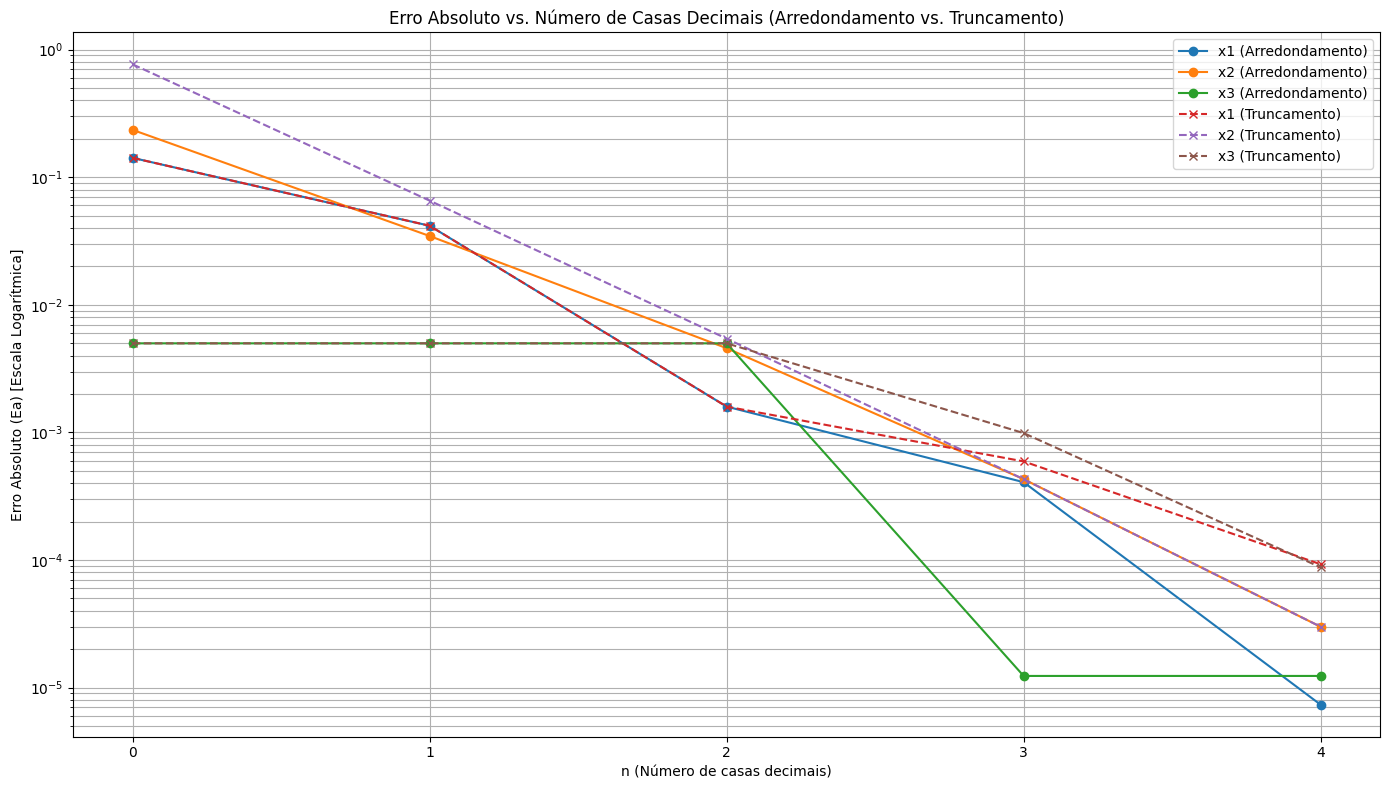

In [4]:


plt.figure(figsize=(14, 8))

# plot do arredondamento
plt.plot(parta_resultado_round['n'], parta_resultado_round['Ea_x1'], marker='o', label='x1 (Arredondamento)')
plt.plot(parta_resultado_round['n'], parta_resultado_round['Ea_x2'], marker='o', label='x2 (Arredondamento)')
plt.plot(parta_resultado_round['n'], parta_resultado_round['Ea_x3'], marker='o', label='x3 (Arredondamento)')
# plot truncado
plt.plot(parta_resultado_truncar['n'], parta_resultado_truncar['Ea_x1'], marker='x', linestyle='--', label='x1 (Truncamento)')
plt.plot(parta_resultado_truncar['n'], parta_resultado_truncar['Ea_x2'], marker='x', linestyle='--', label='x2 (Truncamento)')
plt.plot(parta_resultado_truncar['n'], parta_resultado_truncar['Ea_x3'], marker='x', linestyle='--', label='x3 (Truncamento)')
plt.yscale('log')
plt.xlabel('n (Número de casas decimais)')
plt.ylabel('Erro Absoluto (Ea) [Escala Logarítmica]')
plt.title('Erro Absoluto vs. Número de Casas Decimais (Arredondamento vs. Truncamento)')
plt.legend()
plt.grid(True, which="both", ls="-")
plt.xticks(n_val)
plt.tight_layout()
plt.savefig('parteA.png', dpi=100)
plt.show()


arredondar sempre gera erro menor ou igual ao truncamento? Justifique com os
resultados

A resposta é sim, como o tratamento do truncamento é simplesmente remover os algarismos menos siginificativos ate que o número tenha a quantidade de casas significativas desejadas, para casos onde o número a ser truncado apresenta o primeiro algarismo a ser descartado superior a 5 o valor do erro sera maior do que o gerado por arredondamento, um ponto onde isso fica claro é quando queremos 4 casas decimais para o pi:
  Com arredondamento o valor vai para 3.1416 e o erro para 0.000007
   já no truncamento o valor do pi fica 3.1415 e o erro é de 0.000093.
Mostrando que para esse caso o truncamento gera um erro muito maior. Quando o primeiro número a ser removido é inferior a 5 o erro será igual para ambos os métodos.
  Isso fica evidente ao analisar o gráfico e para cada um dos valores observados o erro do arredondamento é sempre igual o inferior ao do truncamento.

Parte B


In [5]:


pre_art = [121.7, 120.4, 122.1, 119.8, 121.2, 120.9, 122.4, 121.0 ,120.2, 121.5]
pre_art_round = [0]*len(pre_art)
pre_art_truncar = [0]*len(pre_art)

med_orig= np.mean(pre_art)

for i in range(len(pre_art)):
  pre_art_round[i]= round(pre_art[i], 0)
  pre_art_truncar[i]= truncar(pre_art[i], 0)


print(pre_art_round)
print(pre_art_truncar)

def preArtExt(org):
  media = np.mean(org)
  minimo = np.min(org)
  maximo = np.max(org)
  amplitude = maximo - minimo
  desvio_padrao = np.std(org)
  erroabs_media = abs(media- med_orig)
  erroper_media = (erroabs_media/abs(med_orig))*100
  print(erroabs_media)
  print(erroper_media)
  return media, minimo, maximo, amplitude, desvio_padrao, erroabs_media, erroper_media

resultadosc = []
media_orig, min_orig, max_orig, amp_orig, std_orig, eab_orig, epr_orig = preArtExt(pre_art)
resultadosc.append({
    "Case": "Original",
    "media" : f"{media_orig:.6e}",
    "minimo": f"{min_orig:.6e}",
    "maximo": f"{max_orig:.6e}",
    "amplitude": f"{amp_orig:.6e}",
    "desvio_padrao": f"{std_orig:.6e}",
    "erro_absoluto": f"{0:.6e}",
    "erro_percentual": f"{0:.6e}"
})


media_round, min_round, max_round, amp_round, std_round, eab_round, epr_round = preArtExt(pre_art_round)
resultadosc.append({
    "Case": "Arredondado",
    "media" : f"{media_round:.6e}",
    "minimo": f"{min_round:.6e}",
    "maximo": f"{max_round:.6e}",
    "amplitude": f"{amp_round:.6e}",
    "desvio_padrao": f"{std_round:.6e}",
    "erro_absoluto": f"{eab_round:.6e}",
    "erro_percentual": f"{epr_round:.6e}"
})


media_trunc, min_trunc, max_trunc, amp_trunc, std_trunc, eab_trunc, epr_trunc = preArtExt(pre_art_truncar)
resultadosc.append({
    "Case": "Truncado",
    "media" : f"{media_trunc:.6e}",
    "minimo": f"{min_trunc:.6e}",
    "maximo": f"{max_trunc:.6e}",
    "amplitude": f"{amp_trunc:.6e}",
    "desvio_padrao": f"{std_trunc:.6e}",
    "erro_absoluto": f"{eab_trunc:.6e}",
    "erro_percentual": f"{epr_trunc:.6e}"

})

df_resultadosc = pd.DataFrame(resultadosc)
display(df_resultadosc)


[122.0, 120.0, 122.0, 120.0, 121.0, 121.0, 122.0, 121.0, 120.0, 122.0]
[121.0, 120.0, 122.0, 119.0, 121.0, 120.0, 122.0, 121.0, 120.0, 121.0]
0.0
0.0
0.020000000000010232
0.01651254953765706
0.4200000000000017
0.3467635402906223


,Case,media,minimo,maximo,amplitude,desvio_padrao,erro_absoluto,erro_percentual
0,Original,1.211200e+02,1.198000e+02,1.224000e+02,2.600000e+00,7.909488e-01,0.000000e+00,0.000000e+00
1,Arredondado,1.211000e+02,1.200000e+02,1.220000e+02,2.000000e+00,8.306624e-01,2.000000e-02,1.651255e-02
2,Truncado,1.207000e+02,1.190000e+02,1.220000e+02,3.000000e+00,9.000000e-01,4.200000e-01,3.467635e-01


B.2

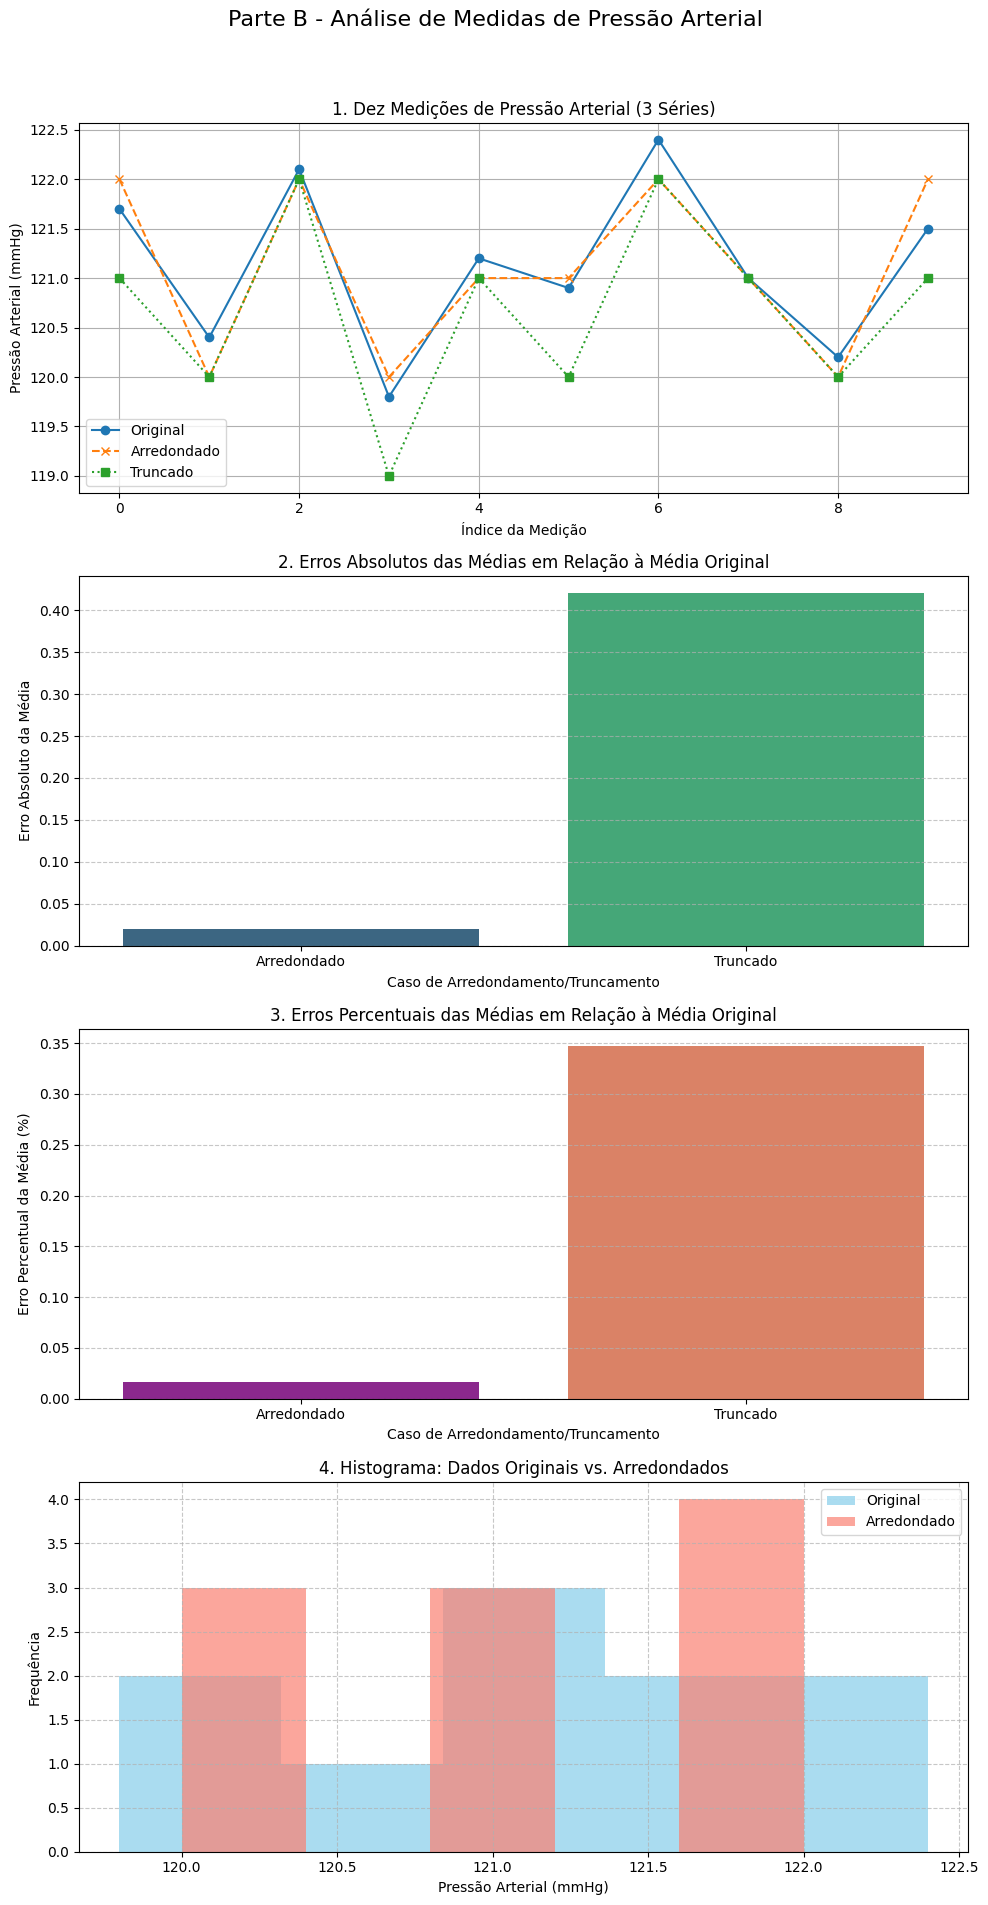

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns


fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(10, 20))
fig.suptitle('Parte B - Análise de Medidas de Pressão Arterial', fontsize=16)
#medições
indices = range(len(pre_art))
axes[0].plot(indices, pre_art, marker='o', label='Original')
axes[0].plot(indices, pre_art_round, marker='x', linestyle='--', label='Arredondado')
axes[0].plot(indices, pre_art_truncar, marker='s', linestyle=':', label='Truncado')
axes[0].set_title('1. Dez Medições de Pressão Arterial (3 Séries)')
axes[0].set_xlabel('Índice da Medição')
axes[0].set_ylabel('Pressão Arterial (mmHg)')
axes[0].legend()
axes[0].grid(True)
#Erro absoluto
df_plot_errors = df_resultadosc[df_resultadosc['Case'] != 'Original'].copy()
df_plot_errors['erro_absoluto'] = df_plot_errors['erro_absoluto'].astype(float)
df_plot_errors['erro_percentual'] = df_plot_errors['erro_percentual'].astype(float)
sns.barplot(x='Case', y='erro_absoluto', hue='Case', data=df_plot_errors, palette='viridis', ax=axes[1], legend=False)
axes[1].set_title('2. Erros Absolutos das Médias em Relação à Média Original')
axes[1].set_xlabel('Caso de Arredondamento/Truncamento')
axes[1].set_ylabel('Erro Absoluto da Média')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

#Erro percentual
sns.barplot(x='Case', y='erro_percentual', hue='Case', data=df_plot_errors, palette='plasma', ax=axes[2], legend=False)
axes[2].set_title('3. Erros Percentuais das Médias em Relação à Média Original')
axes[2].set_xlabel('Caso de Arredondamento/Truncamento')
axes[2].set_ylabel('Erro Percentual da Média (%)')
axes[2].grid(axis='y', linestyle='--', alpha=0.7)

#Histograma
axes[3].hist(pre_art, bins=5, alpha=0.7, label='Original', color='skyblue')
axes[3].hist(pre_art_round, bins=5, alpha=0.7, label='Arredondado', color='salmon')
axes[3].set_title('4. Histograma: Dados Originais vs. Arredondados')
axes[3].set_xlabel('Pressão Arterial (mmHg)')
axes[3].set_ylabel('Frequência')
axes[3].legend()
axes[3].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.savefig('parteB.png')
plt.show()


Explique se a representação inteira é suficiente para preservar a média e a variabilidade
desta pequena amostra. Não faça interpretação médica dos valores.

Por meio da representação inteira dos valores se perde parte da precisão e com isso tanto a média quanto a variabilidade são alterados, sendo assim em contextos onde é necessário maior precissão na análise essas alterações podem ser prejudicias. É necessário levar em consideração a forma de como essa aproximação inteira é calculada, para o arredondamento o erro porcentual foi de aproximadamente 1,6%, por outro lado o de truncamento foi de 34%.


Parte C

In [7]:
r_base = 0.8 * 1e-3
L_base = 0.2
mu_base = 3.5 * 1e-3
dp_base = 1200.0

r_arr = round(0.80, 1) * 1e-3
r_tru = truncar(0.80, 1) * 1e-3

mu_arr = round(0.0035, 3)
mu_tru = truncar(0.0035, 3)

#PA para centenas
dp_arr = round(1200 / 100) * 100.0
dp_tru =  truncar(1200, -2)

def calcHagen( raio, comprimento, deltaP, visc):
  vazao = (math.pi * (raio**4) * deltaP)/(8*visc*comprimento)
  return vazao

cenarios = {
    "1. Base (valores originais)": (r_base, L_base, mu_base, dp_base),
    "2. r arredondado (1 casa mm)": (r_arr, L_base, mu_base, dp_base),
    "2. r truncado (1 casa mm)": (r_tru, L_base, mu_base, dp_base),
    "3. mu arredondado (3 casas Pa.s)": (r_base, L_base, mu_arr, dp_base),
    "3. mu truncado (3 casas Pa.s)": (r_base, L_base, mu_tru, dp_base),
    "4. dp arredondado (centenas)": (r_base, L_base, mu_base, dp_arr),
    "4. dp truncado (centenas)": (r_base, L_base, mu_base, dp_tru),
    "5. Todas aprox. (Arredondamento)": (r_arr, L_base, mu_arr, dp_arr),
    "5. Todas aprox. (Truncamento)": (r_tru, L_base, mu_tru, dp_tru),
}
q_ref= calcHagen(r_base, L_base, dp_base, mu_base)
resultadosc= []



for nome, (raio, comprimento, visc, deltaP) in cenarios.items():
  val_q= calcHagen(raio, comprimento, deltaP, visc)
  erro=calcErro(val_q, q_ref)
  resultadosc.append({
      "Caso": nome,
      "Q (m³/s)": f"{val_q:.6e}",
        "Erro Absoluto (m³/s)": f"{erro[0]:.6e}",
        "Erro Relativo (%)": f"{erro[1]:.4f}%"
  })

df_resultados= pd.DataFrame(resultadosc)
display(df_resultados)

,Caso,Q (m³/s),Erro Absoluto (m³/s),Erro Relativo (%)
0,1. Base (valores originais),2.757421e-07,0.000000e+00,0.0000%
1,2. r arredondado (1 casa mm),2.757421e-07,0.000000e+00,0.0000%
2,2. r truncado (1 casa mm),2.757421e-07,0.000000e+00,0.0000%
3,3. mu arredondado (3 casas Pa.s),2.412743e-07,3.446776e-08,0.1250%
4,3. mu truncado (3 casas Pa.s),3.216991e-07,4.595701e-08,0.1667%
5,4. dp arredondado (centenas),2.757421e-07,0.000000e+00,0.0000%
6,4. dp truncado (centenas),2.757421e-07,0.000000e+00,0.0000%
7,5. Todas aprox. (Arredondamento),2.412743e-07,3.446776e-08,0.1250%
8,5. Todas aprox. (Truncamento),3.216991e-07,4.595701e-08,0.1667%


In [8]:
import numpy as np
deltar = np.arange(0.7, 0.9, 0.01)
resultados_r = []


for num in deltar:
  r_arr = round(num, 1) * 1e-3
  r_tru = truncar(num, 1) * 1e-3
  r_temp = num * 1e-3

  val_q= calcHagen(r_temp, L_base, dp_base , mu_base)
  val_arr= calcHagen(r_arr, L_base, dp_base , mu_base)
  val_tru= calcHagen(r_tru, L_base, dp_base , mu_base)
  erro_arr=calcErro(val_arr, val_q)
  erro_tru=calcErro(val_tru, val_q)
  resultados_r.append({
      "n": num,
      "Q (m³/s)": f"{val_q:.6e}",
        "Q do arredondamento (m³/s)": f"{val_arr:.6e}",
        "Erro Absoluto do arredondamento(m³/s)": f"{erro_arr[0]:.6e}",
        "Erro Relativo do arredondamento(%)": f"{erro_arr[1]:.4f}",
        "Erro Percentual do arredondamento(%)": f"{erro_arr[2]:.4f}",
        "Q do truncamento (m³/s)": f"{val_tru:.6e}",
        "Erro Absoluto do truncamento(m³/s)": f"{erro_tru[0]:.6e}",
        "Erro Relativo do truncamento(%)": f"{erro_tru[1]:.4f}",
        "Erro Percentual do truncamento(%)": f"{erro_tru[2]:.4f}",
        "raio arredondado": f"{r_arr:.4f}",
        "raio truncado": f"{r_tru:.4f}"
        })

  parteC_df_resultados_r = pd.DataFrame(resultados_r)
display( parteC_df_resultados_r)


,n,Q (m³/s),Q do arredondamento (m³/s),Erro Absoluto do arredondamento(m³/s),Erro Relativo do arredondamento(%),Erro Percentual do arredondamento(%),Q do truncamento (m³/s),Erro Absoluto do truncamento(m³/s),Erro Relativo do truncamento(%),Erro Percentual do truncamento(%),raio arredondado,raio truncado
0,0.70,1.616349e-07,1.616349e-07,0.000000e+00,0.0000,0.0000,1.616349e-07,0.000000e+00,0.0000,0.0000,0.0007,0.0007
1,0.71,1.710710e-07,1.616349e-07,9.436094e-09,0.0552,5.5159,1.616349e-07,9.436094e-09,0.0552,5.5159,0.0007,0.0007
2,0.72,1.809144e-07,1.616349e-07,1.927943e-08,0.1066,10.6567,1.616349e-07,1.927943e-08,0.1066,10.6567,0.0007,0.0007
3,0.73,1.911765e-07,1.616349e-07,2.954157e-08,0.1545,15.4525,1.616349e-07,2.954157e-08,0.1545,15.4525,0.0007,0.0007
4,0.74,2.018692e-07,1.616349e-07,4.023422e-08,0.1993,19.9308,1.616349e-07,4.023422e-08,0.1993,19.9308,0.0007,0.0007
5,0.75,2.130042e-07,2.757421e-07,6.273789e-08,0.2945,29.4538,1.616349e-07,5.136925e-08,0.2412,24.1165,0.0008,0.0007
6,0.76,2.245936e-07,2.757421e-07,5.114843e-08,0.2277,22.7738,1.616349e-07,6.295870e-08,0.2803,28.0323,0.0008,0.0007
7,0.77,2.366497e-07,2.757421e-07,3.909236e-08,0.1652,16.5191,1.616349e-07,7.501478e-08,0.3170,31.6987,0.0008,0.0007
8,0.78,2.491848e-07,2.757421e-07,2.655730e-08,0.1066,10.6577,1.616349e-07,8.754983e-08,0.3513,35.1345,0.0008,0.0007
9,0.79,2.622113e-07,2.757421e-07,1.353074e-08,0.0516,5.1602,1.616349e-07,1.005764e-07,0.3836,38.3570,0.0008,0.0007


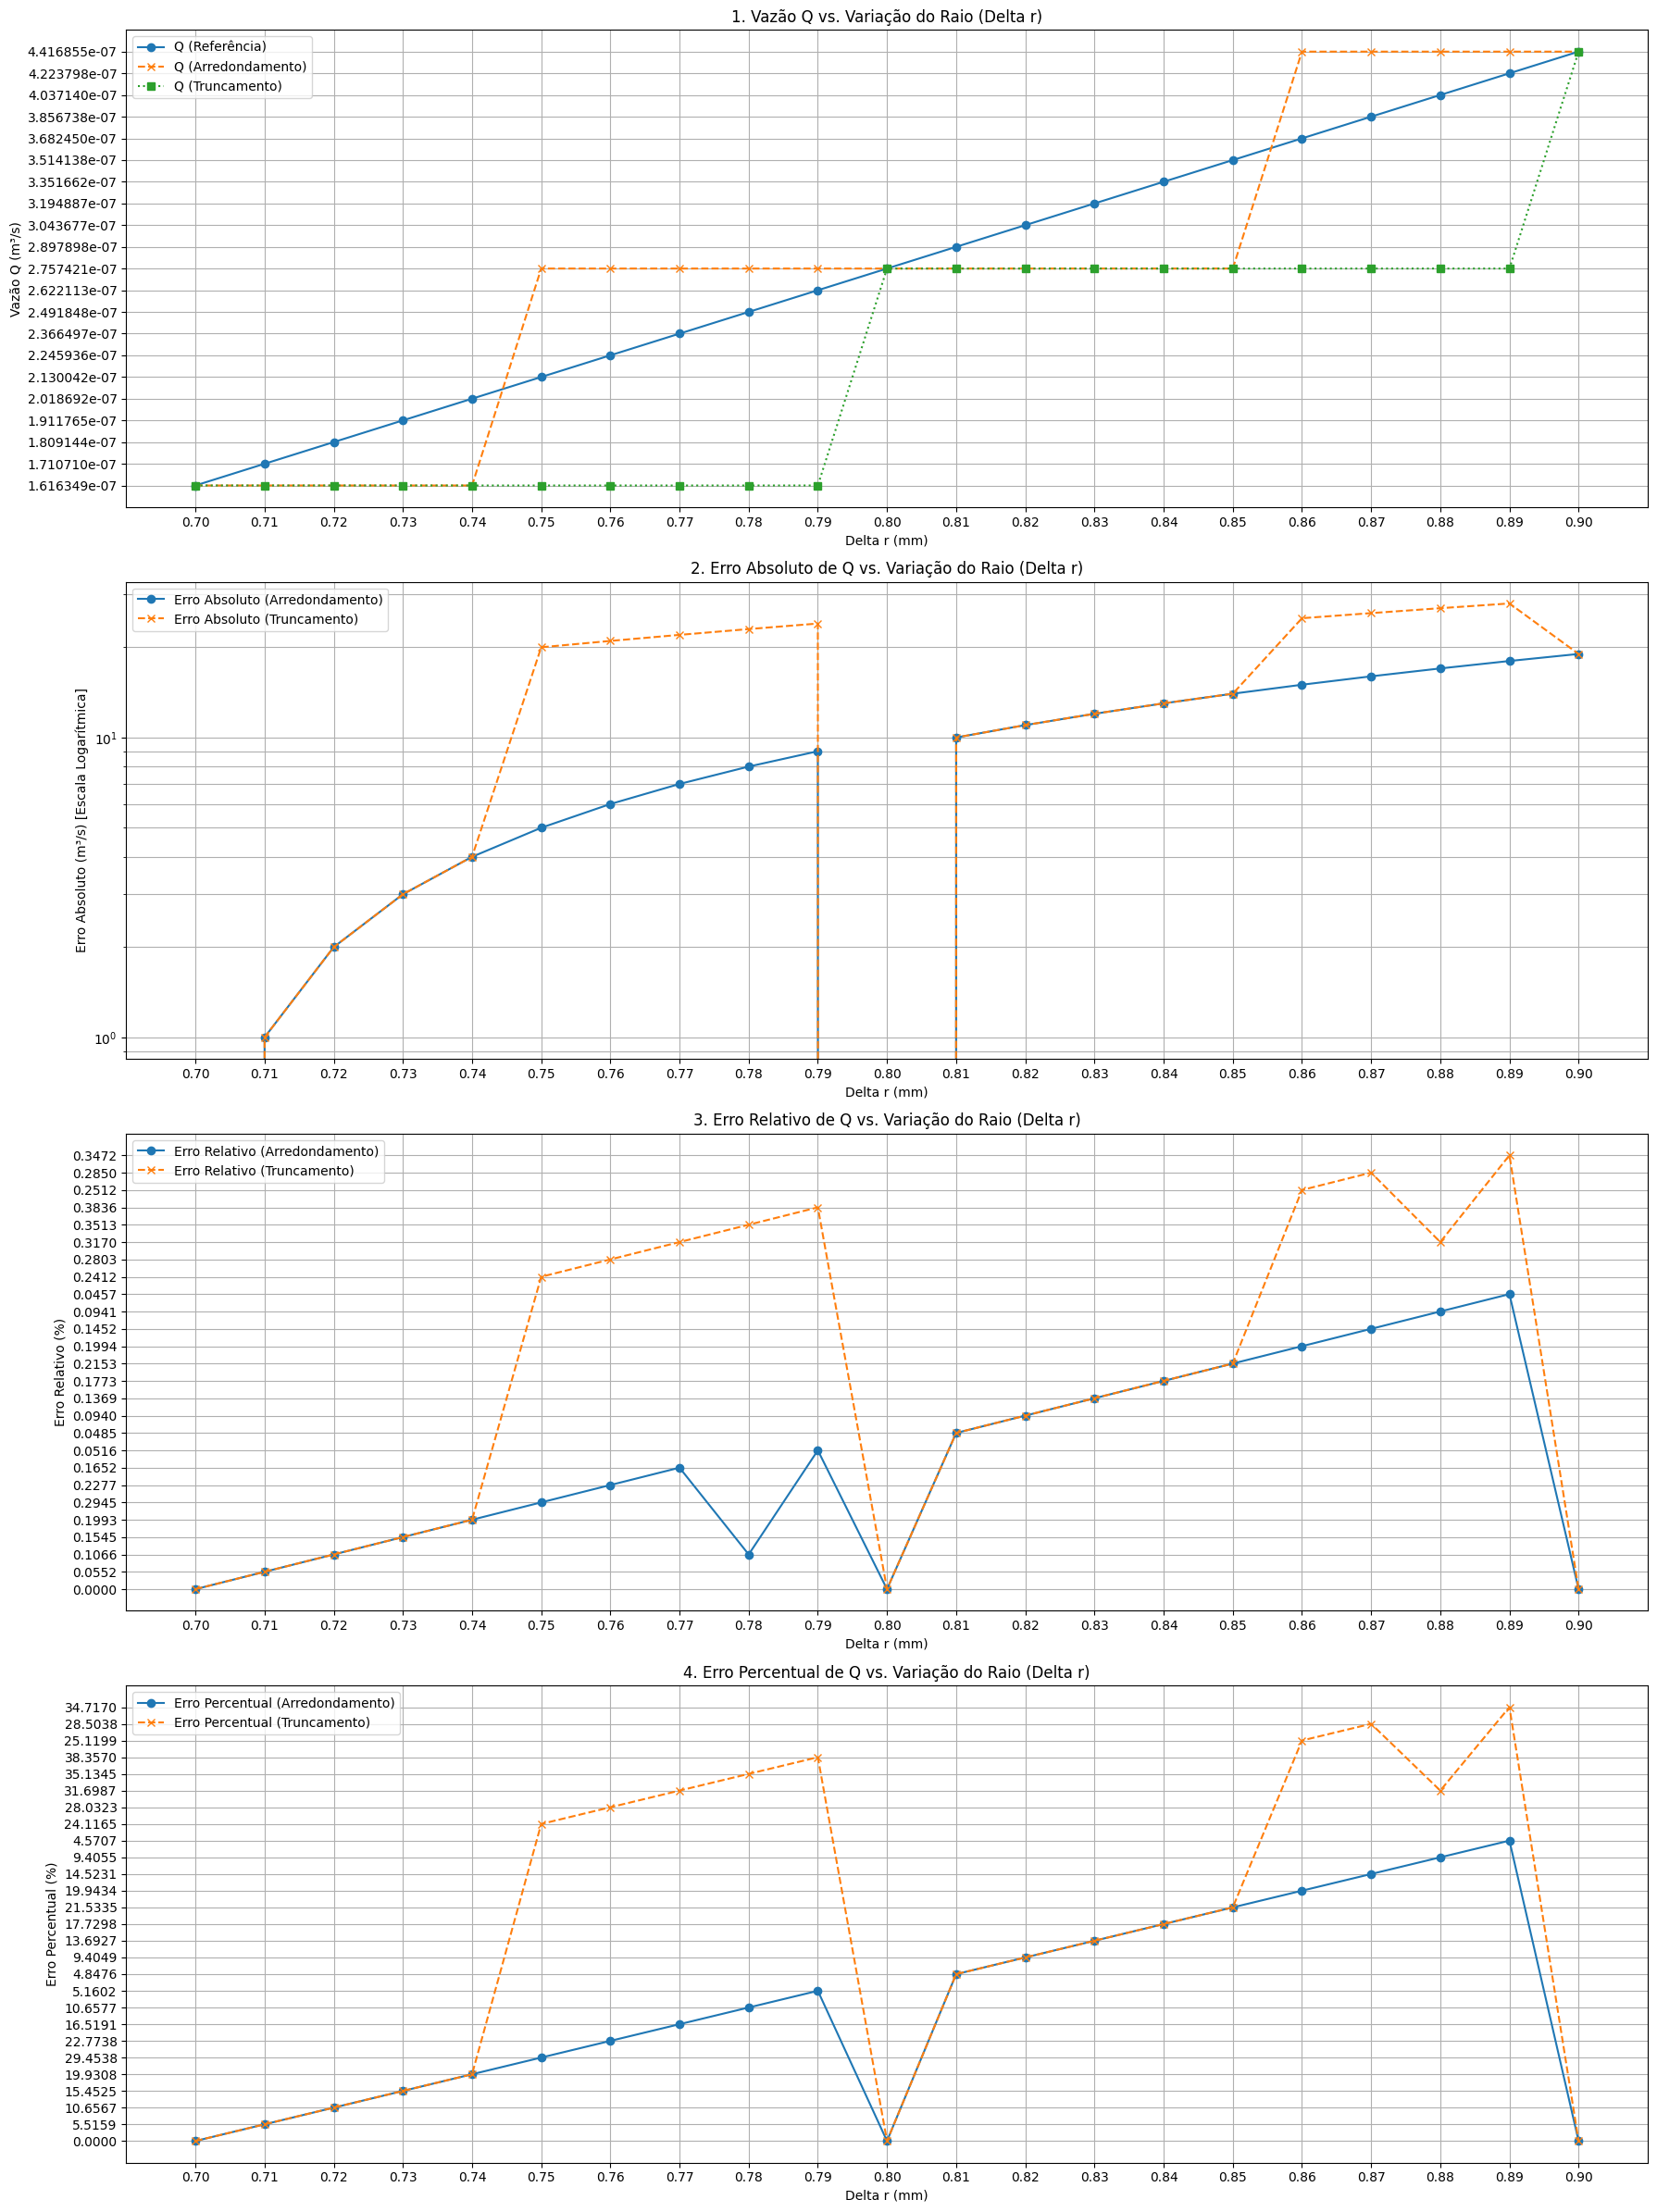

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 24)) #tamanho da figura

# Valor de Q por r
plt.subplot(4, 1, 1)
plt.plot(parteC_df_resultados_r['n'], parteC_df_resultados_r['Q (m³/s)'], marker='o', label='Q (Referência)')
plt.plot(parteC_df_resultados_r['n'], parteC_df_resultados_r['Q do arredondamento (m³/s)'], marker='x', linestyle='--', label='Q (Arredondamento)')
plt.plot(parteC_df_resultados_r['n'], parteC_df_resultados_r['Q do truncamento (m³/s)'], marker='s', linestyle=':', label='Q (Truncamento)')
plt.xlabel('Delta r (mm)')
plt.ylabel('Vazão Q (m³/s)')
plt.title('1. Vazão Q vs. Variação do Raio (Delta r)')
plt.legend()
plt.grid(True)
plt.xticks(deltar)
# Erro absoluto em função de r
plt.subplot(4, 1, 2)
plt.plot(parteC_df_resultados_r['n'], parteC_df_resultados_r['Erro Absoluto do arredondamento(m³/s)'], marker='o', label='Erro Absoluto (Arredondamento)')
plt.plot(parteC_df_resultados_r['n'], parteC_df_resultados_r['Erro Absoluto do truncamento(m³/s)'], marker='x', linestyle='--', label='Erro Absoluto (Truncamento)')
plt.yscale('log')
plt.xlabel('Delta r (mm)')
plt.ylabel('Erro Absoluto (m³/s) [Escala Logarítmica]')
plt.title('2. Erro Absoluto de Q vs. Variação do Raio (Delta r)')
plt.legend()
plt.grid(True, which="both", ls="-")
plt.xticks(deltar)

# Erro relativo em função de r
plt.subplot(4, 1, 3)
plt.plot(parteC_df_resultados_r['n'], parteC_df_resultados_r['Erro Relativo do arredondamento(%)'], marker='o', label='Erro Relativo (Arredondamento)')
plt.plot(parteC_df_resultados_r['n'], parteC_df_resultados_r['Erro Relativo do truncamento(%)'], marker='x', linestyle='--', label='Erro Relativo (Truncamento)')
plt.xlabel('Delta r (mm)')
plt.ylabel('Erro Relativo (%)')
plt.title('3. Erro Relativo de Q vs. Variação do Raio (Delta r)')
plt.legend()
plt.grid(True)
plt.xticks(deltar)

# Porcentagem de erro em função de r
plt.subplot(4, 1, 4)
plt.plot(parteC_df_resultados_r['n'], parteC_df_resultados_r['Erro Percentual do arredondamento(%)'], marker='o', label='Erro Percentual (Arredondamento)')
plt.plot(parteC_df_resultados_r['n'], parteC_df_resultados_r['Erro Percentual do truncamento(%)'], marker='x', linestyle='--', label='Erro Percentual (Truncamento)')
plt.xlabel('Delta r (mm)')
plt.ylabel('Erro Percentual (%)')
plt.title('4. Erro Percentual de Q vs. Variação do Raio (Delta r)')
plt.legend()
plt.grid(True)
plt.xticks(deltar)

plt.tight_layout()
plt.savefig('parteC.png')
plt.show()


Parte D

In [10]:
import numpy as np

raiod = 50 * 1e-9
comprimentod = 10 * 1e-6
viscod = 3.5 * 1e-3
deltaPd = 5000
resultadosdQ = []

# Qd = calcHagen(raiod, comprimentod, deltaPd, viscod)
Qd = calcHagen(raiod, comprimentod, deltaPd, viscod)
#def calcHagen( raio, comprimento, deltaP, visc):

raioerro = np.arange(0.1, 5.1, 0.1)
for r in raioerro:
  QdP= calcHagen((raiod + (r * 1e-9)), comprimentod, deltaPd, viscod)
  QdN= calcHagen((raiod - (r * 1e-9)), comprimentod, deltaPd, viscod)
  erroP=calcErro(QdP, Qd)
  erroN=calcErro(QdN, Qd)
  apxLP= 4*(raiod + (r * 1e-9))/raiod
  apxLN= 4*(raiod - (r * 1e-9))/raiod
  #append para criação da tabela
  resultadosdQ.append({
      "raio (nm)": r,
      "Q (m³/s)": Qd,
      "Q+ (m³/s)": QdP,
      "Erro Absoluto Q+ (m³/s)": erroP[0],
      "Erro Relativo Q+ (%)": erroP[1],
      "Erro Percentual Q+ (%)": erroP[2],
      "Apx Linear+": apxLP,
      "Q- (m³/s)": QdN,
      "Erro Absoluto Q- (m³/s)": erroN[0],
      "Erro Relativo Q- (%)": erroN[1],
      "Erro Percentual Q- (%)": erroN[2],
      "Apx Linear-": apxLN
  })

print("Valores de variação do raio (nm):")
print(raioerro)
parteD_df_resultadosdQ = pd.DataFrame(resultadosdQ)
display(parteD_df_resultadosdQ)

Valores de variação do raio (nm):
[0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8
 1.9 2.  2.1 2.2 2.3 2.4 2.5 2.6 2.7 2.8 2.9 3.  3.1 3.2 3.3 3.4 3.5 3.6
 3.7 3.8 3.9 4.  4.1 4.2 4.3 4.4 4.5 4.6 4.7 4.8 4.9 5. ]


,raio (nm),Q (m³/s),Q+ (m³/s),Erro Absoluto Q+ (m³/s),Erro Relativo Q+ (%),Erro Percentual Q+ (%),Apx Linear+,Q- (m³/s),Erro Absoluto Q- (m³/s),Erro Relativo Q- (%),Erro Percentual Q- (%),Apx Linear-
0,0.1,3.506242e-19,3.534376e-19,2.813420e-21,0.008024,0.802403,4.008,3.478276e-19,2.796590e-21,0.007976,0.797603,3.992
1,0.2,3.506242e-19,3.562679e-19,5.643737e-21,0.016096,1.609626,4.016,3.450478e-19,5.576417e-21,0.015904,1.590426,3.984
2,0.3,3.506242e-19,3.591152e-19,8.491019e-21,0.024217,2.421687,4.024,3.422846e-19,8.339548e-21,0.023785,2.378486,3.976
3,0.4,3.506242e-19,3.619795e-19,1.135533e-20,0.032386,3.238605,4.032,3.395381e-19,1.108605e-20,0.031618,3.161804,3.968
4,0.5,3.506242e-19,3.648609e-19,1.423675e-20,0.040604,4.060401,4.040,3.368082e-19,1.381599e-20,0.039404,3.940399,3.960
5,0.6,3.506242e-19,3.677595e-19,1.713533e-20,0.048871,4.887093,4.048,3.340947e-19,1.652944e-20,0.047143,4.714289,3.952
6,0.7,3.506242e-19,3.706753e-19,2.005115e-20,0.057187,5.718701,4.056,3.313977e-19,1.922646e-20,0.054835,5.483494,3.944
7,0.8,3.506242e-19,3.736085e-19,2.298427e-20,0.065552,6.555245,4.064,3.287171e-19,2.190711e-20,0.062480,6.248032,3.936
8,0.9,3.506242e-19,3.765590e-19,2.593477e-20,0.073967,7.396743,4.072,3.260527e-19,2.457147e-20,0.070079,7.007922,3.928
9,1.0,3.506242e-19,3.795269e-19,2.890271e-20,0.082432,8.243216,4.080,3.234046e-19,2.721960e-20,0.077632,7.763184,3.920


C.2

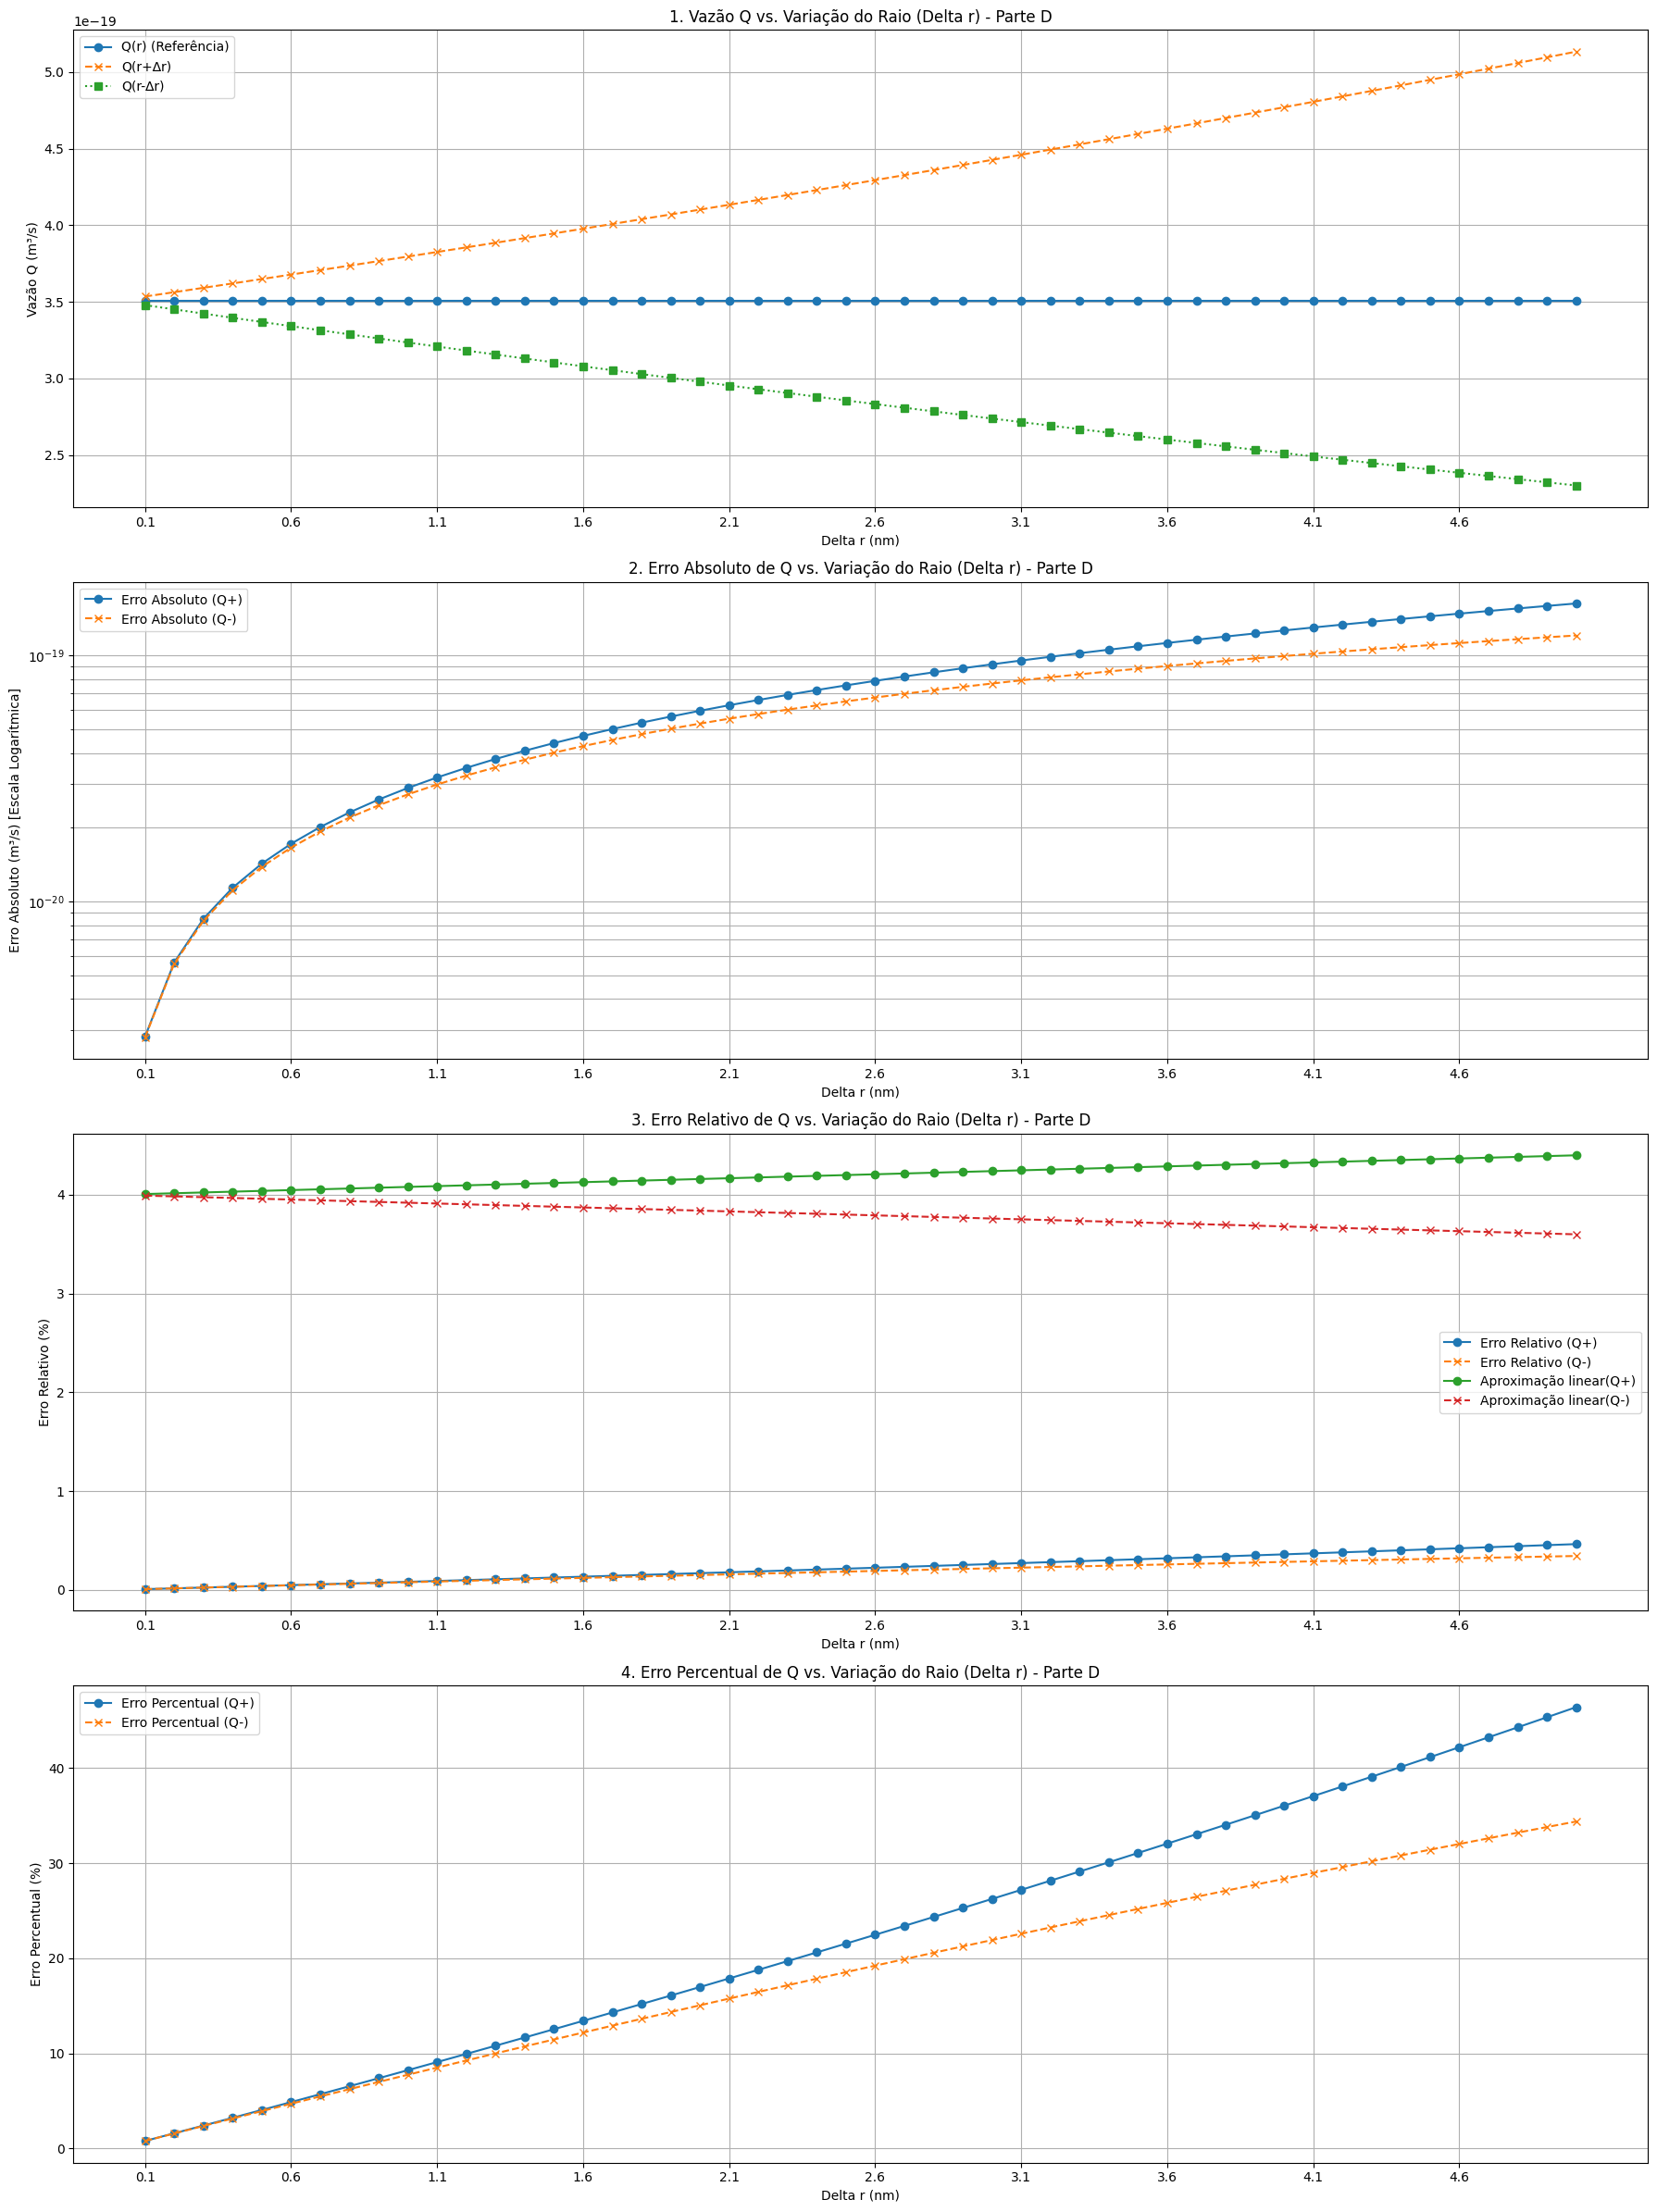

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 24))
passo= 5
# Valor de Q por r
plt.subplot(4, 1, 1)
plt.plot(parteD_df_resultadosdQ['raio (nm)'], parteD_df_resultadosdQ['Q (m³/s)'], marker='o', label='Q(r) (Referência)')
plt.plot(parteD_df_resultadosdQ['raio (nm)'], parteD_df_resultadosdQ['Q+ (m³/s)'], marker='x', linestyle='--', label='Q(r+∆r)')
plt.plot(parteD_df_resultadosdQ['raio (nm)'], parteD_df_resultadosdQ['Q- (m³/s)'], marker='s', linestyle=':', label='Q(r-∆r)')
plt.xlabel('Delta r (nm)')
plt.ylabel('Vazão Q (m³/s)')
plt.title('1. Vazão Q vs. Variação do Raio (Delta r) - Parte D')
plt.legend()
plt.grid(True)
plt.xticks(raioerro[::passo])



# Erro absoluto em função de r
plt.subplot(4, 1, 2)
plt.plot(parteD_df_resultadosdQ['raio (nm)'], parteD_df_resultadosdQ['Erro Absoluto Q+ (m³/s)'], marker='o', label='Erro Absoluto (Q+)')
plt.plot(parteD_df_resultadosdQ['raio (nm)'], parteD_df_resultadosdQ['Erro Absoluto Q- (m³/s)'], marker='x', linestyle='--', label='Erro Absoluto (Q-)')
plt.yscale('log')
plt.xlabel('Delta r (nm)')
plt.ylabel('Erro Absoluto (m³/s) [Escala Logarítmica]')
plt.title('2. Erro Absoluto de Q vs. Variação do Raio (Delta r) - Parte D')
plt.legend()
plt.grid(True, which="both", ls="-")
plt.xticks(raioerro[::passo])

# Erro relativo em função de r
plt.subplot(4, 1, 3)
plt.plot(parteD_df_resultadosdQ['raio (nm)'], parteD_df_resultadosdQ['Erro Relativo Q+ (%)'], marker='o', label='Erro Relativo (Q+)')
plt.plot(parteD_df_resultadosdQ['raio (nm)'], parteD_df_resultadosdQ['Erro Relativo Q- (%)'], marker='x', linestyle='--', label='Erro Relativo (Q-)')
plt.plot(parteD_df_resultadosdQ['raio (nm)'], parteD_df_resultadosdQ['Apx Linear+'], marker='o', label='Aproximação linear(Q+)')
plt.plot(parteD_df_resultadosdQ['raio (nm)'], parteD_df_resultadosdQ['Apx Linear-'], marker='x', linestyle='--', label='Aproximação linear(Q-)')
plt.xlabel('Delta r (nm)')
plt.ylabel('Erro Relativo (%)')
plt.title('3. Erro Relativo de Q vs. Variação do Raio (Delta r) - Parte D')
plt.legend()
plt.grid(True)
plt.xticks(raioerro[::passo])
# Porcentagem de erro em função de r
plt.subplot(4, 1, 4)
plt.plot(parteD_df_resultadosdQ['raio (nm)'], parteD_df_resultadosdQ['Erro Percentual Q+ (%)'], marker='o', label='Erro Percentual (Q+)')
plt.plot(parteD_df_resultadosdQ['raio (nm)'], parteD_df_resultadosdQ['Erro Percentual Q- (%)'], marker='x', linestyle='--', label='Erro Percentual (Q-)')
plt.xlabel('Delta r (nm)')
plt.ylabel('Erro Percentual (%)')
plt.title('4. Erro Percentual de Q vs. Variação do Raio (Delta r) - Parte D')
plt.legend()
plt.grid(True)
plt.xticks(raioerro[::passo])

plt.tight_layout()
plt.savefig('parteD.png')
plt.show()


O erro relativo tem uma propagação muito menor, já que na função base o raio está elevado a 4, o que faz o resultado final ser superior ao da fórmula fornecida

Resultados da precisão de cálculo (float64 vs float32):


<>:106: SyntaxWarning: invalid escape sequence '\d'
<>:108: SyntaxWarning: invalid escape sequence '\d'
<>:111: SyntaxWarning: invalid escape sequence '\D'
<>:113: SyntaxWarning: invalid escape sequence '\d'
<>:124: SyntaxWarning: invalid escape sequence '\D'
<>:125: SyntaxWarning: invalid escape sequence '\d'
<>:126: SyntaxWarning: invalid escape sequence '\D'
<>:106: SyntaxWarning: invalid escape sequence '\d'
<>:108: SyntaxWarning: invalid escape sequence '\d'
<>:111: SyntaxWarning: invalid escape sequence '\D'
<>:113: SyntaxWarning: invalid escape sequence '\d'
<>:124: SyntaxWarning: invalid escape sequence '\D'
<>:125: SyntaxWarning: invalid escape sequence '\d'
<>:126: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_3919/3319484730.py:106: SyntaxWarning: invalid escape sequence '\d'
  marker='o', label='$\delta_1$ (Equação 6)')
/tmp/ipykernel_3919/3319484730.py:108: SyntaxWarning: invalid escape sequence '\d'
  marker='x', linestyle='--', label='$\delta_2$ (Equação 7)'

,Medida,Float64,Float32,Diferenca Absoluta,Diferenca Relativa
0,r^4,6.25000e-30,6.25000e-30,3.95977e-37,6.33564e-08
1,Q,3.50624e-19,3.50624e-19,5.22863e-26,1.49123e-07
2,np.finfo().eps,2.22045e-16,1.19209e-07,1.19209e-07,5.36871e+08



--- Comparação de variação de vazão (Eq. 6 vs Eq. 7) ---


,dr/r,Delta1 (Eq. 6),Delta2 (Eq. 7),Erro Absoluto (entre delta1 e delta2),Erro Relativo (entre delta1 e delta2)
0,1e-01,4.64100e-01,4.64100e-01,2.22045e-16,4.78441e-16
1,1e-02,4.06040e-02,4.06040e-02,1.04083e-16,2.56338e-15
2,1e-03,4.00600e-03,4.00600e-03,2.21177e-16,5.52114e-14
3,1e-04,4.00060e-04,4.00060e-04,1.24141e-16,3.10306e-13
4,1e-05,4.00006e-05,4.00006e-05,2.26544e-16,5.66352e-12
5,1e-06,4.00001e-06,4.00001e-06,5.35759e-16,1.33939e-10
6,1e-07,4.00000e-07,4.00000e-07,1.86636e-16,4.66589e-10
7,1e-08,4.00000e-08,4.00000e-08,3.17446e-16,7.93615e-09
8,1e-09,4.00000e-09,4.00000e-09,3.66771e-16,9.16926e-08
9,1e-10,4.00000e-10,4.00000e-10,2.79162e-16,6.97906e-07


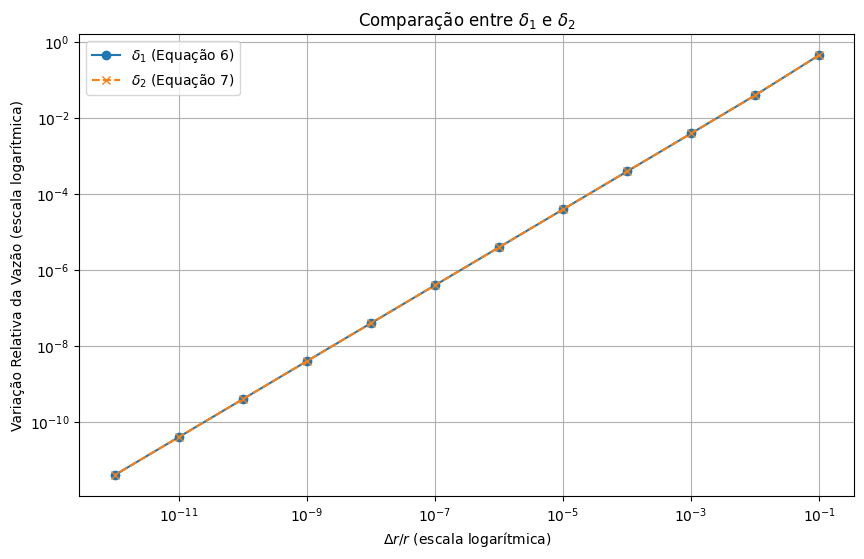

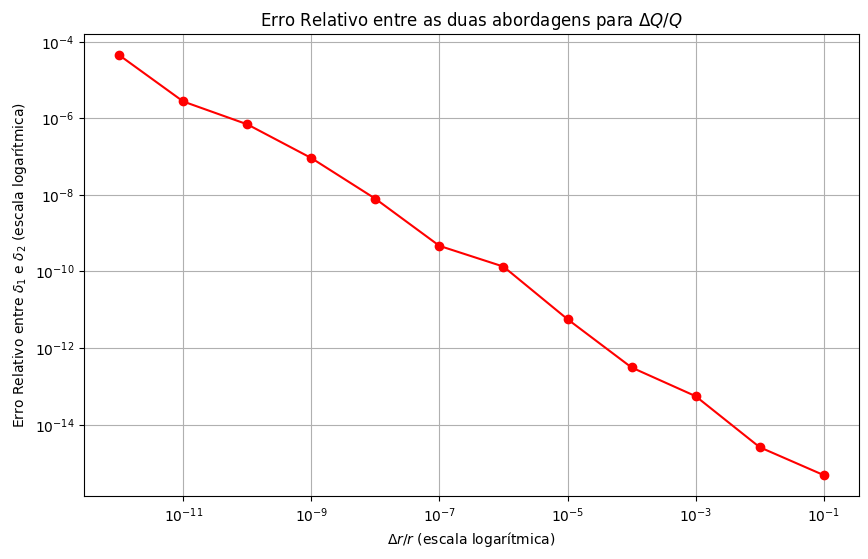

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
raiod_base = 50 * 1e-9
comprimentod_base = 10 * 1e-6
viscod_base = 3.5 * 1e-3
deltaPd_base = 5000
resultados_precisao = []


raiod_64 = np.float64(raiod_base)
comprimentod_64 = np.float64(comprimentod_base)
viscod_64 = np.float64(viscod_base)
deltaPd_64 = np.float64(deltaPd_base)
r4_64 = raiod_64**4
Q_64 = calcHagen(raiod_64, comprimentod_64, deltaPd_64, viscod_64)

raiod_32 = np.float32(raiod_base)
comprimentod_32 = np.float32(comprimentod_base)
viscod_32 = np.float32(viscod_base)
deltaPd_32 = np.float32(deltaPd_base)
r4_32 = raiod_32**4
Q_32 = calcHagen(raiod_32, comprimentod_32, deltaPd_32, viscod_32)

erro_Q_abs = np.abs(Q_64 - Q_32)
erro_Q_rel = erro_Q_abs / Q_64

resultados_precisao.append({
    "Medida": "r^4",
    "Float64": f"{r4_64:.5e}",
    "Float32": f"{r4_32:.5e}",
    "Diferenca Absoluta": f"{np.abs(r4_64 - r4_32):.5e}",
    "Diferenca Relativa": f"{np.abs(r4_64 - r4_32) / r4_64:.5e}"
})
resultados_precisao.append({
    "Medida": "Q",
    "Float64": f"{Q_64:.5e}",
    "Float32": f"{Q_32:.5e}",
    "Diferenca Absoluta": f"{erro_Q_abs:.5e}",
    "Diferenca Relativa": f"{erro_Q_rel:.5e}"
})


eps_32 = np.finfo(np.float32).eps
eps_64 = np.finfo(np.float64).eps

resultados_precisao.append({
    "Medida": "np.finfo().eps",
    "Float64": f"{eps_64:.5e}",
    "Float32": f"{eps_32:.5e}",
    "Diferenca Absoluta": f"{np.abs(eps_64 - eps_32):.5e}",
    "Diferenca Relativa": f"{np.abs(eps_64 - eps_32) / eps_64:.5e}" if eps_64 != 0 else "N/A"
})

print("Resultados da precisão de cálculo (float64 vs float32):")
df_precisao = pd.DataFrame(resultados_precisao)
display(df_precisao)


print("\n--- Comparação de variação de vazão (Eq. 6 vs Eq. 7) ---")


delta_r_over_r_values = np.logspace(-1, -12, 12)
comparacao_delta_Q = []

for dr_over_r in delta_r_over_r_values:

    dr = raiod_base * dr_over_r
    r_plus_dr_64 = np.float64(raiod_base + dr)


    Q_r_64 = calcHagen(raiod_64, comprimentod_64, deltaPd_64, viscod_64)
    Q_r_plus_dr_64 = calcHagen(r_plus_dr_64, comprimentod_64, deltaPd_64, viscod_64)

    #EQ 6
    delta1 = (Q_r_plus_dr_64 - Q_r_64) / Q_r_64 if Q_r_64 != 0 else np.nan

    #EQ 7
    delta2 = ((1 + dr_over_r)**4) - 1
    erro_abs_delta = np.abs(delta1 - delta2)
    erro_rel_delta = erro_abs_delta / np.abs(delta2) if np.abs(delta2) != 0 else np.nan
    comparacao_delta_Q.append({
        "dr/r": f"{dr_over_r:.0e}",
        "Delta1 (Eq. 6)": f"{delta1:.5e}",
        "Delta2 (Eq. 7)": f"{delta2:.5e}",
        "Erro Absoluto (entre delta1 e delta2)": f"{erro_abs_delta:.5e}",
        "Erro Relativo (entre delta1 e delta2)": f"{erro_rel_delta:.5e}"
    })

df_comparacao_delta_Q = pd.DataFrame(comparacao_delta_Q)
display(df_comparacao_delta_Q)
plt.figure(figsize=(10, 6))
plt.plot(delta_r_over_r_values, [float(row['Delta1 (Eq. 6)']) for index, row in df_comparacao_delta_Q.iterrows()],
         marker='o', label='$\delta_1$ (Equação 6)')
plt.plot(delta_r_over_r_values, [float(row['Delta2 (Eq. 7)']) for index, row in df_comparacao_delta_Q.iterrows()],
         marker='x', linestyle='--', label='$\delta_2$ (Equação 7)')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$\Delta r / r$ (escala logarítmica)')
plt.ylabel('Variação Relativa da Vazão (escala logarítmica)')
plt.title('Comparação entre $\delta_1$ e $\delta_2$')
plt.legend()
plt.grid(True, which="both", ls="-")
plt.show()


plt.figure(figsize=(10, 6))
plt.plot(delta_r_over_r_values, [float(row['Erro Relativo (entre delta1 e delta2)']) for index, row in df_comparacao_delta_Q.iterrows()],
         marker='o', color='red')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$\Delta r / r$ (escala logarítmica)')
plt.ylabel('Erro Relativo entre $\delta_1$ e $\delta_2$ (escala logarítmica)')
plt.title('Erro Relativo entre as duas abordagens para $\Delta Q / Q$')
plt.grid(True, which="both", ls="-")
plt.show()

Explique, em um parágrafo, que a redução da escala aumenta a razão superfície/volume e
torna os efeitos viscosos e de parede mais importantes.

Isso ocorre justamente por uma questão geométrica, a superfície é um valor de duas dimensões, já o volume possui 3 dimensões, de forma simplificada teriamos L^2/L^3 => 1/L, quanto menor o L maior o resultado. A ampplificação do efeito de parede ocorre justamente por uma área de contato maior do fluído com a parede, já que proporcionalmente uma maior parte desse fluído tera contato direto com a parede em comparação em um cenario onde a relação superfície/volume seja menor. Já em relação a viscosidade o motivo é semelhante, quanto maior o contato do fluído com a parede, maior vai ser a influência da viscosidade com o escoamento, isso pode ser observado na equação do número de reynolds, já que quanto menor o comprimento menor será o resultante o que indica uma maior influência da viscosidade.

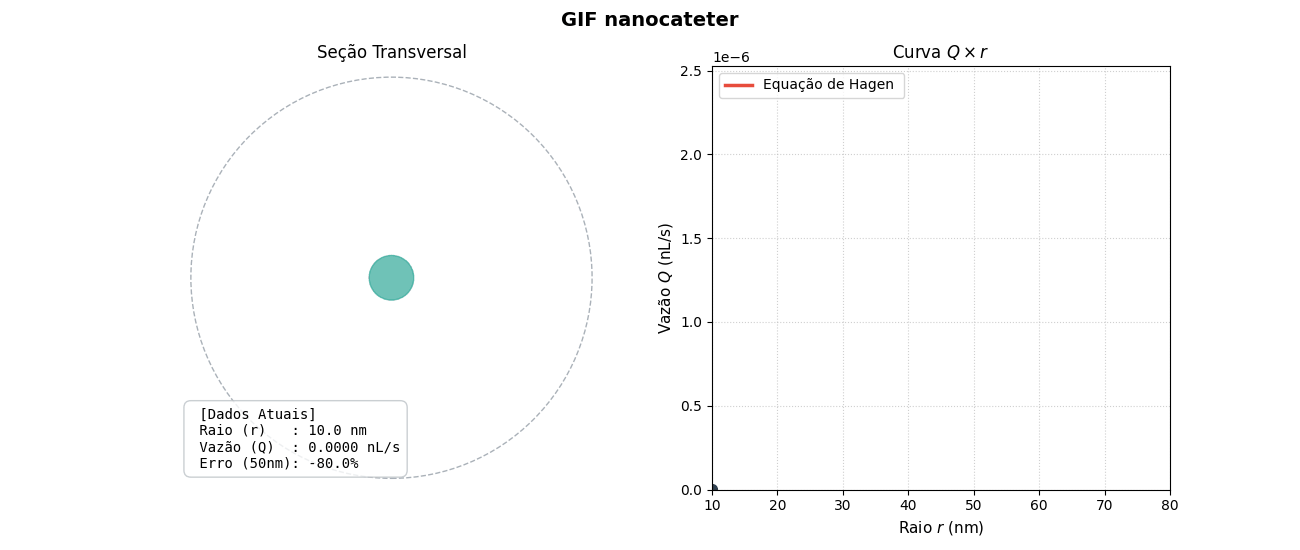

In [49]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import imageio.v3 as iio

def calcQ(raio_nm):
    r_metros = raio_nm * 1e-9
    q_m3_s = calcHagen(r_metros, comprimentod, deltaPd, viscod)
    # Conversão
    q_nl_s = q_m3_s * 1e12
    return q_nl_s
raios = np.linspace(10, 80, 100)
raio_alvo = 50.0
vazoes = calcQ(raios)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))
fig.suptitle("GIF nanocateter", fontsize=14, fontweight='bold')
#  Seção Transversal
ax1.set_xlim(-95, 95)
ax1.set_ylim(-95, 95)
ax1.set_aspect('equal')
ax1.set_title("Seção Transversal")
ax1.axis('off')

# Parede do Gif
parede_externa = plt.Circle((0, 0), 90, color='#2c3e50', fill=False, linestyle='--', alpha=0.4, label='Limite Físico')
ax1.add_patch(parede_externa)
canal = plt.Circle((0, 0), raios[0], color='#32a899', alpha=0.7)  # Azul fluido
ax1.add_patch(canal)

# Texto das especificações
texto_dados = ax1.text(-90, -85, "", fontsize=10, fontfamily='monospace',
                        bbox=dict(facecolor='white', alpha=0.8, edgecolor='#bdc3c7', boxstyle='round,pad=0.5'))

#Gráfico Curva Q x r
ax2.set_xlim(min(raios), max(raios))
ax2.set_ylim(0, max(vazoes) * 1.1)
ax2.set_xlabel("Raio $r$ (nm)", fontsize=11)
ax2.set_ylabel("Vazão $Q$ (nL/s)", fontsize=11)
ax2.set_title("Curva $Q \\times r$")
ax2.grid(True, linestyle=':', alpha=0.6)

linha_q, = ax2.plot([], [], color='#e74c3c', lw=2.5, label='Equação de Hagen ')
ponto_atual, = ax2.plot([], [], 'o', color='#2c3e50', markersize=7)
ax2.legend(loc='upper left')

#Animação
def init():
    canal.set_radius(raios[0])
    linha_q.set_data([], [])
    ponto_atual.set_data([], [])
    texto_dados.set_text("")
    return canal, linha_q, ponto_atual, texto_dados
def update(frame):
    r_atual = raios[frame]
    q_atual = vazoes[frame]

    # Erro percentual
    erro_pct = ((r_atual - raio_alvo) / raio_alvo) * 100

    canal.set_radius(r_atual)
    info_text = (
        f" [Dados Atuais] \n"
        f" Raio (r)   : {r_atual:.1f} nm\n"
        f" Vazão (Q)  : {q_atual:.4f} nL/s\n"
        f" Erro (50nm): {erro_pct:+.1f}%"
    )
    texto_dados.set_text(info_text)

    # Atualização das curvas
    linha_q.set_data(raios[:frame+1], vazoes[:frame+1])
    ponto_atual.set_data([r_atual], [q_atual])

    return canal, linha_q, ponto_atual, texto_dados

# GIF
ani = FuncAnimation(fig, update, frames=len(raios), init_func=init, blit=True)
ani.save('nanocateter.gif', writer='imageio', fps=20)
plt.close()

from IPython.display import Image
Image(filename='nanocateter.gif')



/tmp/ipykernel_3919/104228574.py:134: UserWarning:

Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations



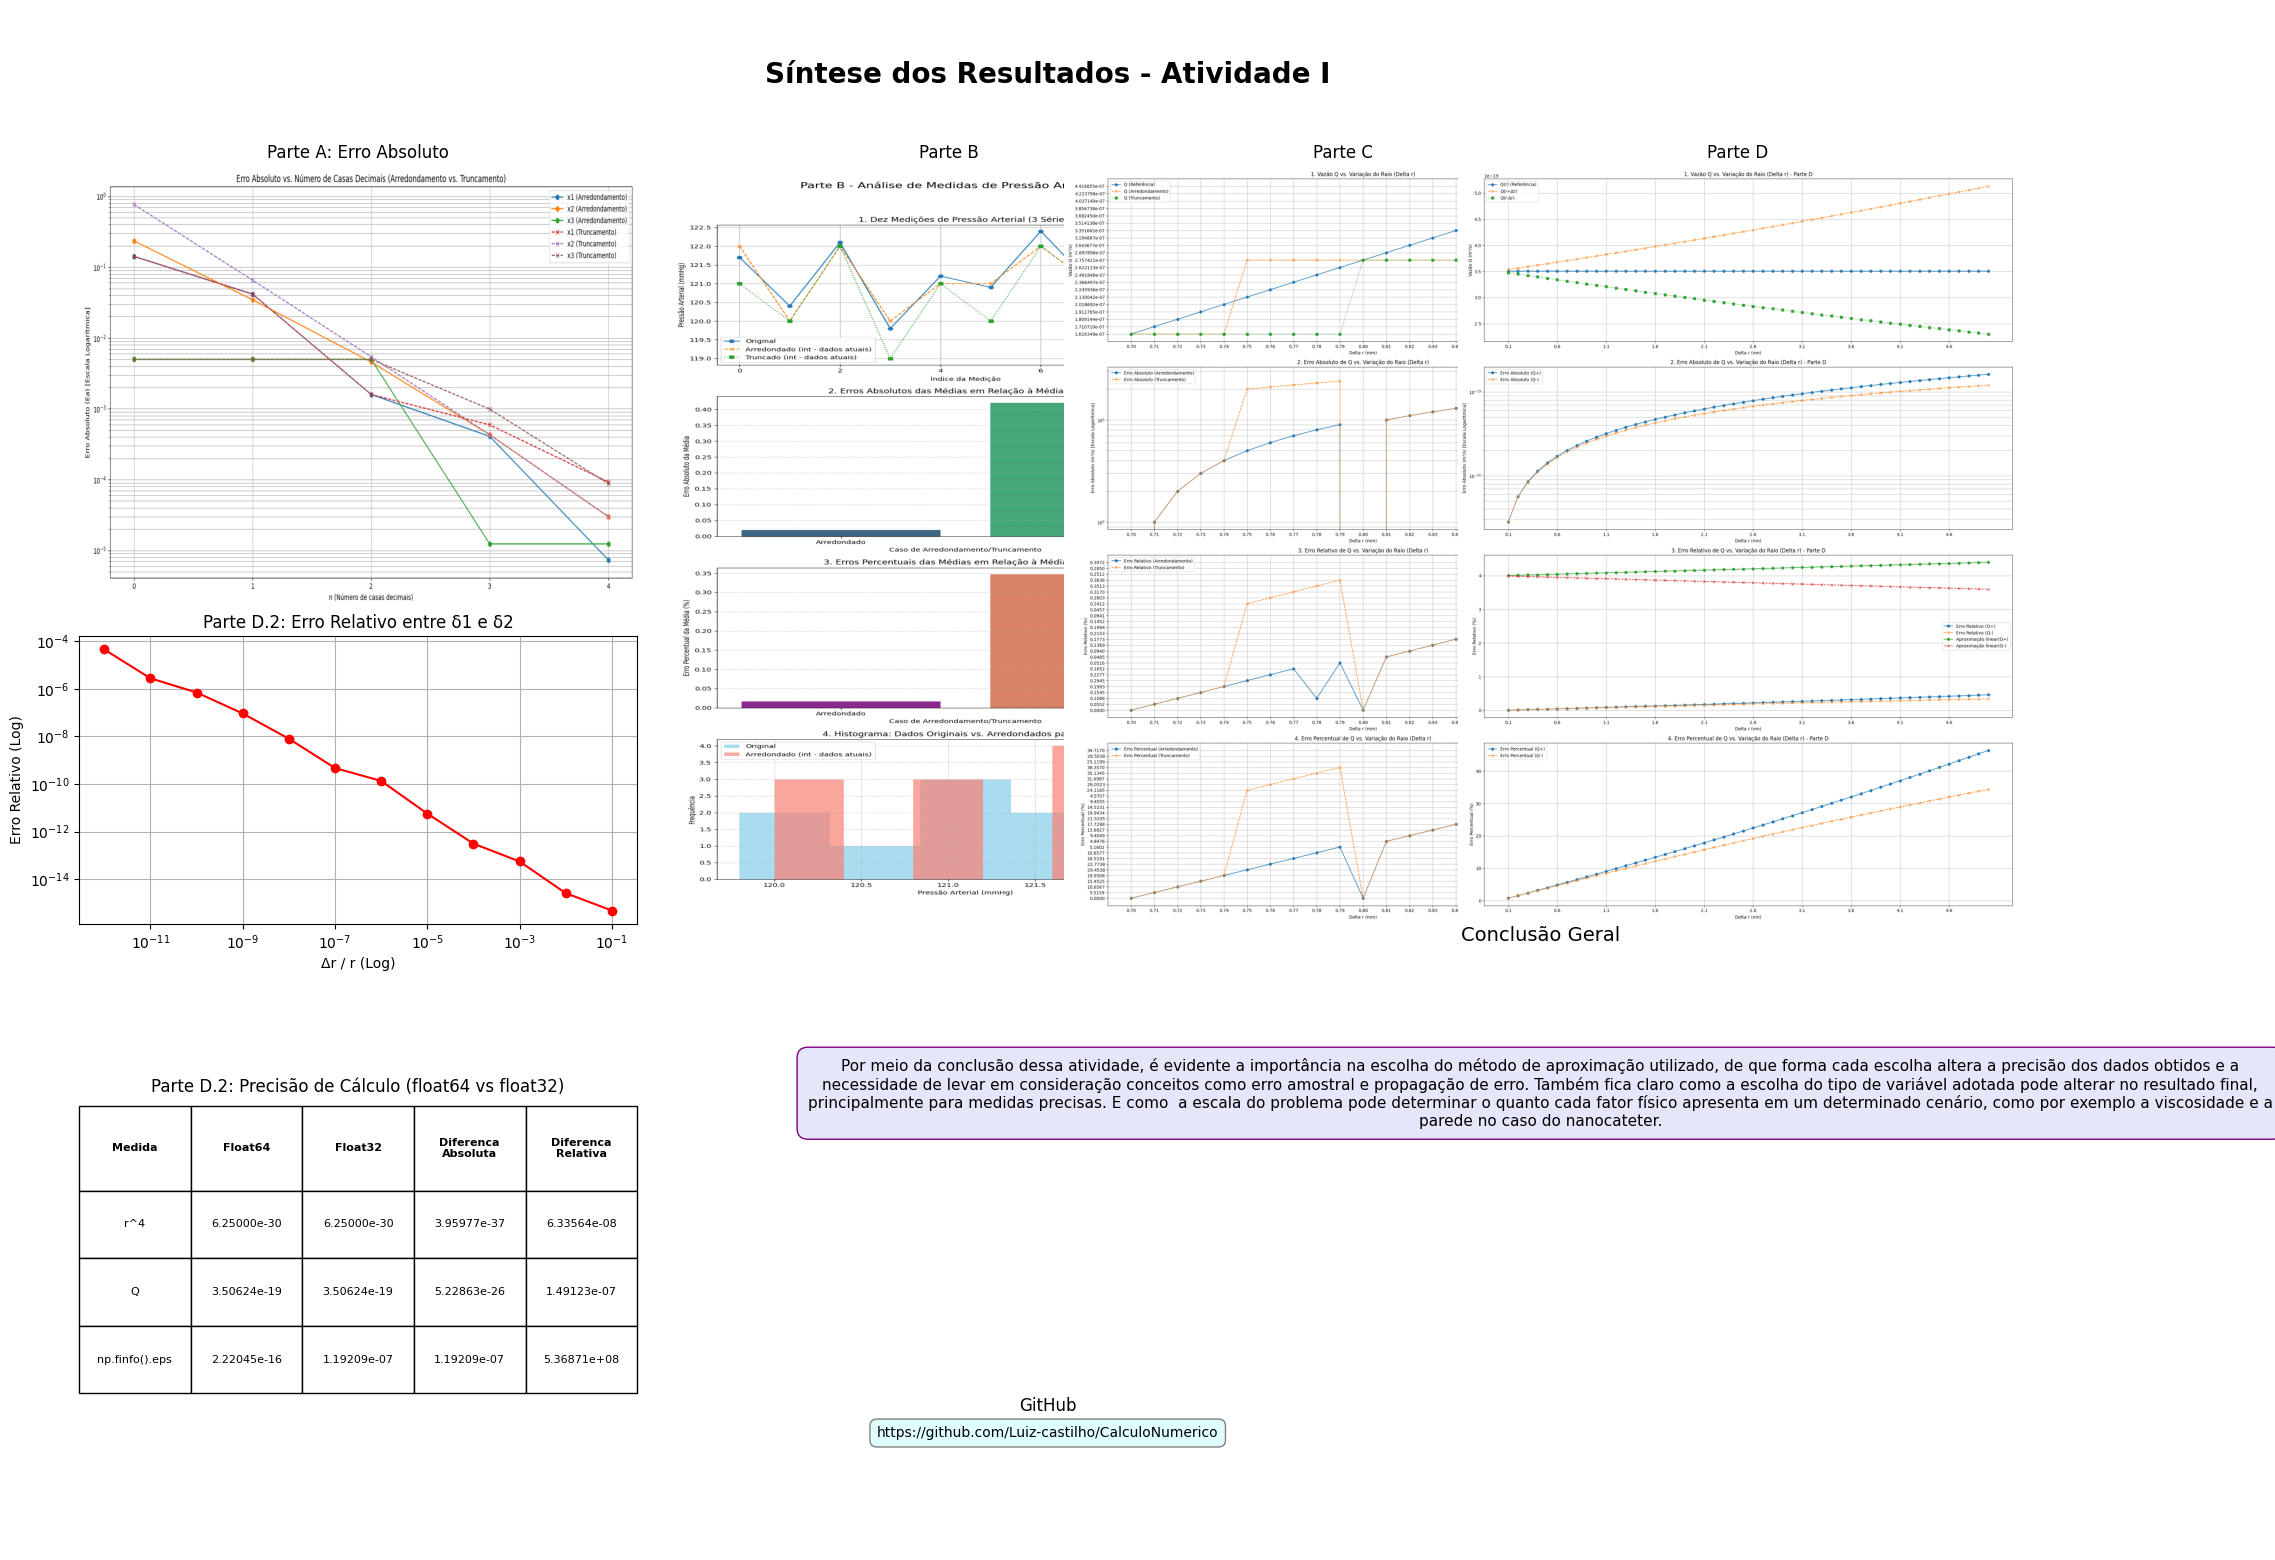

In [44]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib import gridspec
import matplotlib.image as mpimg
import textwrap

# Configura quantidade de grid e tamanho
fig = plt.figure(figsize=(25, 20))
gs = gridspec.GridSpec(10, 10, figure=fig)

# Título Geral  (Linha 0, todas as colunas)
ax_title = fig.add_subplot(gs[0, :])
ax_title.text(0.5, 0.5, "Síntese dos Resultados - Atividade I",
              horizontalalignment='center', verticalalignment='center',
              fontsize=20, fontweight='bold', transform=ax_title.transAxes)
ax_title.axis('off')


#2 Parte A
ax_part_a_plot = fig.add_subplot(gs[1:4, 0:3])
ax_part_a_plot.set_title("Parte A: Erro Absoluto", fontsize=12)

img_parteA = mpimg.imread('parteA.png')
ax_part_a_plot.imshow(img_parteA, aspect='auto')
ax_part_a_plot.axis('off')
#3 Parte B
ax_part_b_plot = fig.add_subplot(gs[1:6, 3:6])
ax_part_b_plot.set_title("Parte B", fontsize=12)
img_parteB = mpimg.imread('parteB.png')
ax_part_b_plot.imshow(img_parteB, aspect='auto')
ax_part_b_plot.axis('off')
#4 Parte C
ax_part_c_plot = fig.add_subplot(gs[1:6, 5:8])
ax_part_c_plot.set_title("Parte C", fontsize=12)
img_parteC = mpimg.imread('parteC.png')
ax_part_c_plot.imshow(img_parteC, aspect='auto')
ax_part_c_plot.axis('off')

#5 Parte D1
ax_part_d_plot = fig.add_subplot(gs[1:6, 7:10])
ax_part_d_plot.set_title("Parte D", fontsize=12)
img_parteD = mpimg.imread('parteD.png')
ax_part_d_plot.imshow(img_parteD, aspect='auto')
ax_part_d_plot.axis('off')

#5 parte D2

df_precisao_formatado = df_precisao.copy()
# Quebra do texot
for col in df_precisao_formatado.columns:
    df_precisao_formatado[col] = (
        df_precisao_formatado[col]
        .astype(str)
        .apply(lambda x: '\n'.join(textwrap.wrap(x, width=18)))
    )

# Quebra da coluna
colunas_formatadas = [
    '\n'.join(textwrap.wrap(str(col), width=15))
    for col in df_precisao_formatado.columns
]

ax_precisao_table = fig.add_subplot(gs[7:9, 0:3])
ax_precisao_table.set_title(
    "Parte D.2: Precisão de Cálculo (float64 vs float32)",
    fontsize=12,
    pad=10
)

ax_precisao_table.axis('off')

table_precisao = ax_precisao_table.table(
    cellText=df_precisao_formatado.values,
    colLabels=colunas_formatadas,
    bbox=[0, 0, 1, 1],
    cellLoc='center',
    loc='center'
)

# fonte
table_precisao.auto_set_font_size(False)
table_precisao.set_fontsize(8)

# ajusta altura
for (row, col), cell in table_precisao.get_celld().items():

    if row == 0:
        # Cabeçalho
        cell.set_height(0.20)
        cell.set_text_props(weight='bold')
    else:
        # Dados
        cell.set_height(0.16)

# Ajusta largura das colunas
num_colunas = len(df_precisao_formatado.columns)

for col in range(num_colunas):
    for row in range(len(df_precisao_formatado) + 1):
        table_precisao[(row, col)].set_width(1 / num_colunas)

#5 Parte D.2
ax_precisao_plot = fig.add_subplot(gs[4:6, 0:3])
ax_precisao_plot.set_title("Parte D.2: Erro Relativo entre δ1 e δ2", fontsize=12)
ax_precisao_plot.plot(delta_r_over_r_values, [float(row['Erro Relativo (entre delta1 e delta2)']) for index, row in df_comparacao_delta_Q.iterrows()],
                      marker='o', color='red')
ax_precisao_plot.set_xscale('log')
ax_precisao_plot.set_yscale('log')
ax_precisao_plot.set_xlabel('Δr / r (Log)')
ax_precisao_plot.set_ylabel('Erro Relativo (Log)')
ax_precisao_plot.grid(True, which="both", ls="-")

#6 Conclusão Geral
ax_conclusion = fig.add_subplot(gs[6:8, 5:10])
ax_conclusion.set_title("Conclusão Geral", fontsize=14)
ax_conclusion.axis('off')
conclusion_text = "Por meio da conclusão dessa atividade, é evidente a importância na escolha do método de aproximação utilizado, de que forma cada escolha altera a precisão dos dados obtidos e a necessidade de levar em consideração conceitos como erro amostral e propagação de erro. Também fica claro como a escolha do tipo de variável adotada pode alterar no resultado final, principalmente para medidas precisas. E como  a escala do problema pode determinar o quanto cada fator físico apresenta em um determinado cenário, como por exemplo a viscosidade e a parede no caso do nanocateter."
ax_conclusion.text(0.5, 0.5, conclusion_text, transform=ax_conclusion.transAxes,
                   horizontalalignment='center', verticalalignment='center',
                   wrap=True, fontsize=11,
                   bbox=dict(boxstyle='round,pad=0.7', fc='lavender', ec='purple', lw=1))

# 7 GIT
ax_git = fig.add_subplot(gs[9, :])
ax_git.set_title("GitHub", fontsize=12)
ax_git.axis('off')
git_text = "https://github.com/Luiz-castilho/CalculoNumerico"
ax_git.text(0.5, 0.95, git_text, transform=ax_git.transAxes,
                 verticalalignment='top', horizontalalignment = "center", wrap=True, fontsize=10,
                 bbox=dict(boxstyle='round,pad=0.5', fc='lightcyan', ec='gray', lw=1))


plt.tight_layout(rect=[0, 0.03, 1, 0.95])  #margem nos grids
plt.savefig('sintese_visual_resultados.png', dpi=100)
plt.show()